# Notebook 01: Financial PhraseBank Dataset Analysis and Stratified Splitting

### Project: Efficient Financial Sentiment Fine-Tuning with LoRA and QLoRA

In this notebook, we explore the **Financial PhraseBank** dataset (`takala/financial_phrasebank`, configuration `sentences_50agree`).

### What this notebook does:
1. Installs all required project dependencies.
2. Inspects available hardware (GPU, VRAM, CUDA, PyTorch).
3. Downloads the dataset and checks data quality (missing values, duplicates).
4. Analyzes the class distribution (positive, negative, neutral) and sentence lengths.
5. Creates a fixed, stratified **70% train / 15% validation / 15% test** split with random seed `42`.
6. Saves split metadata to `results/metrics/split_metadata.json` and creates visual charts.

In [ ]:
# drive setup
import os, sys, subprocess
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/llm-project/lora-qlora-financial-sentiment')
sys.path.insert(0, os.getcwd())

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'transformers', 'datasets', 'peft', 'accelerate', 'bitsandbytes',
    'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'pyyaml'],
    check=True)

for d in ['results/metrics', 'results/predictions', 'results/figures',
          'results/logs', 'adapters/lora', 'adapters/qlora']:
    os.makedirs(d, exist_ok=True)

print(f'Working directory: {os.getcwd()}')
print(f'src/ found: {os.path.exists("src")}')  # Must be True!
print('Setup complete! ✅')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/llm-project/lora-qlora-financial-sentiment
src/ found: True
Setup complete! ✅


In [ ]:
# Check hardware
from src.model_utils import detect_hardware, print_hardware_summary

hw = detect_hardware()
print_hardware_summary(hw)

           HARDWARE & RUNTIME ENVIRONMENT SUMMARY           
CUDA Available:        True
GPU Name:              Tesla T4
GPU VRAM:              14.56 GB (14912.69 MB)
CUDA Version:          12.8
BF16 Supported:        True
PyTorch Version:       2.11.0+cu128
Transformers Version:  5.16.1
Compute Dtype:         bfloat16


In [ ]:
# financial phrasebank dataset loaded
from src.data_utils import load_raw_dataset, check_data_quality, ID2LABEL

print('Loading Financial PhraseBank (sentences_50agree)...')
df = load_raw_dataset('takala/financial_phrasebank', 'sentences_50agree')

print(f'Total samples downloaded: {len(df)}')
display(df.head(5))

Loading Financial PhraseBank (sentences_50agree)...


README.md:   0%|          | 0.00/9.58k [00:00<?, ?B/s]

financial_phrasebank.py:   0%|          | 0.00/6.04k [00:00<?, ?B/s]

Loading via `datasets` failed (Dataset scripts are no longer supported, but found financial_phrasebank.py). Using direct Hugging Face Hub download fallback...
Total samples downloaded: 4846


,sentence,label,label_text
0,"According to Gran , the company has no plans t...",1,neutral
1,Technopolis plans to develop in stages an area...,1,neutral
2,The international electronic industry company ...,0,negative
3,With the new production plant the company woul...,2,positive
4,According to the company 's updated strategy f...,2,positive


In [ ]:
# dataset quality and statistics
quality_stats = check_data_quality(df)

print('=== Dataset Quality Summary ===')
print(f'Total sentences:      {quality_stats["total_samples"]}')
print(f'Missing values:       {quality_stats["missing_values"]}')
print(f'Duplicate sentences:  {quality_stats["duplicate_sentences"]}')
print('\nClass counts:')
for label, count in quality_stats['class_distribution'].items():
    pct = (count / quality_stats['total_samples']) * 100
    print(f'  {label:10s}: {count:5d} ({pct:.1f}%)')

print('\nSentence word length statistics:')
for k, v in quality_stats['word_length'].items():
    print(f'  {k:10s}: {v}')

=== Dataset Quality Summary ===
Total sentences:      4846
Missing values:       0
Duplicate sentences:  8

Class counts:
  neutral   :  2879 (59.4%)
  positive  :  1363 (28.1%)
  negative  :   604 (12.5%)

Sentence word length statistics:
  mean      : 23.101114321089558
  std       : 9.958473674837842
  min       : 2
  median    : 21.0
  max       : 81


In [ ]:
# Created a stratified 70 / 15 / 15 train, validation, and test split
from src.data_utils import create_stratified_split, save_split_metadata, check_leakage

train_df, val_df, test_df = create_stratified_split(
    df,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    random_seed=42,
)

print(f'Train split size:      {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)')
print(f'Validation split size: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test split size:       {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)')

# Verify zero sentence leakage across splits
leakage = check_leakage(train_df, val_df, test_df)
print(f'Sentence overlap check: {leakage}')

# Save split metadata to ensure reproducibility
meta = save_split_metadata(train_df, val_df, test_df, 'results/metrics/split_metadata.json')
print('\nSplit metadata successfully saved to results/metrics/split_metadata.json')

Train split size:      3392 (70.0%)
Validation split size: 727 (15.0%)
Test split size:       727 (15.0%)
Sentence overlap check: {'train_val_overlap': 3, 'train_test_overlap': 2, 'val_test_overlap': 0}

Split metadata successfully saved to results/metrics/split_metadata.json


Saved plots to results/figures/:
 - class_distribution.png
 - split_distribution.png
 - sentence_length_distribution.png


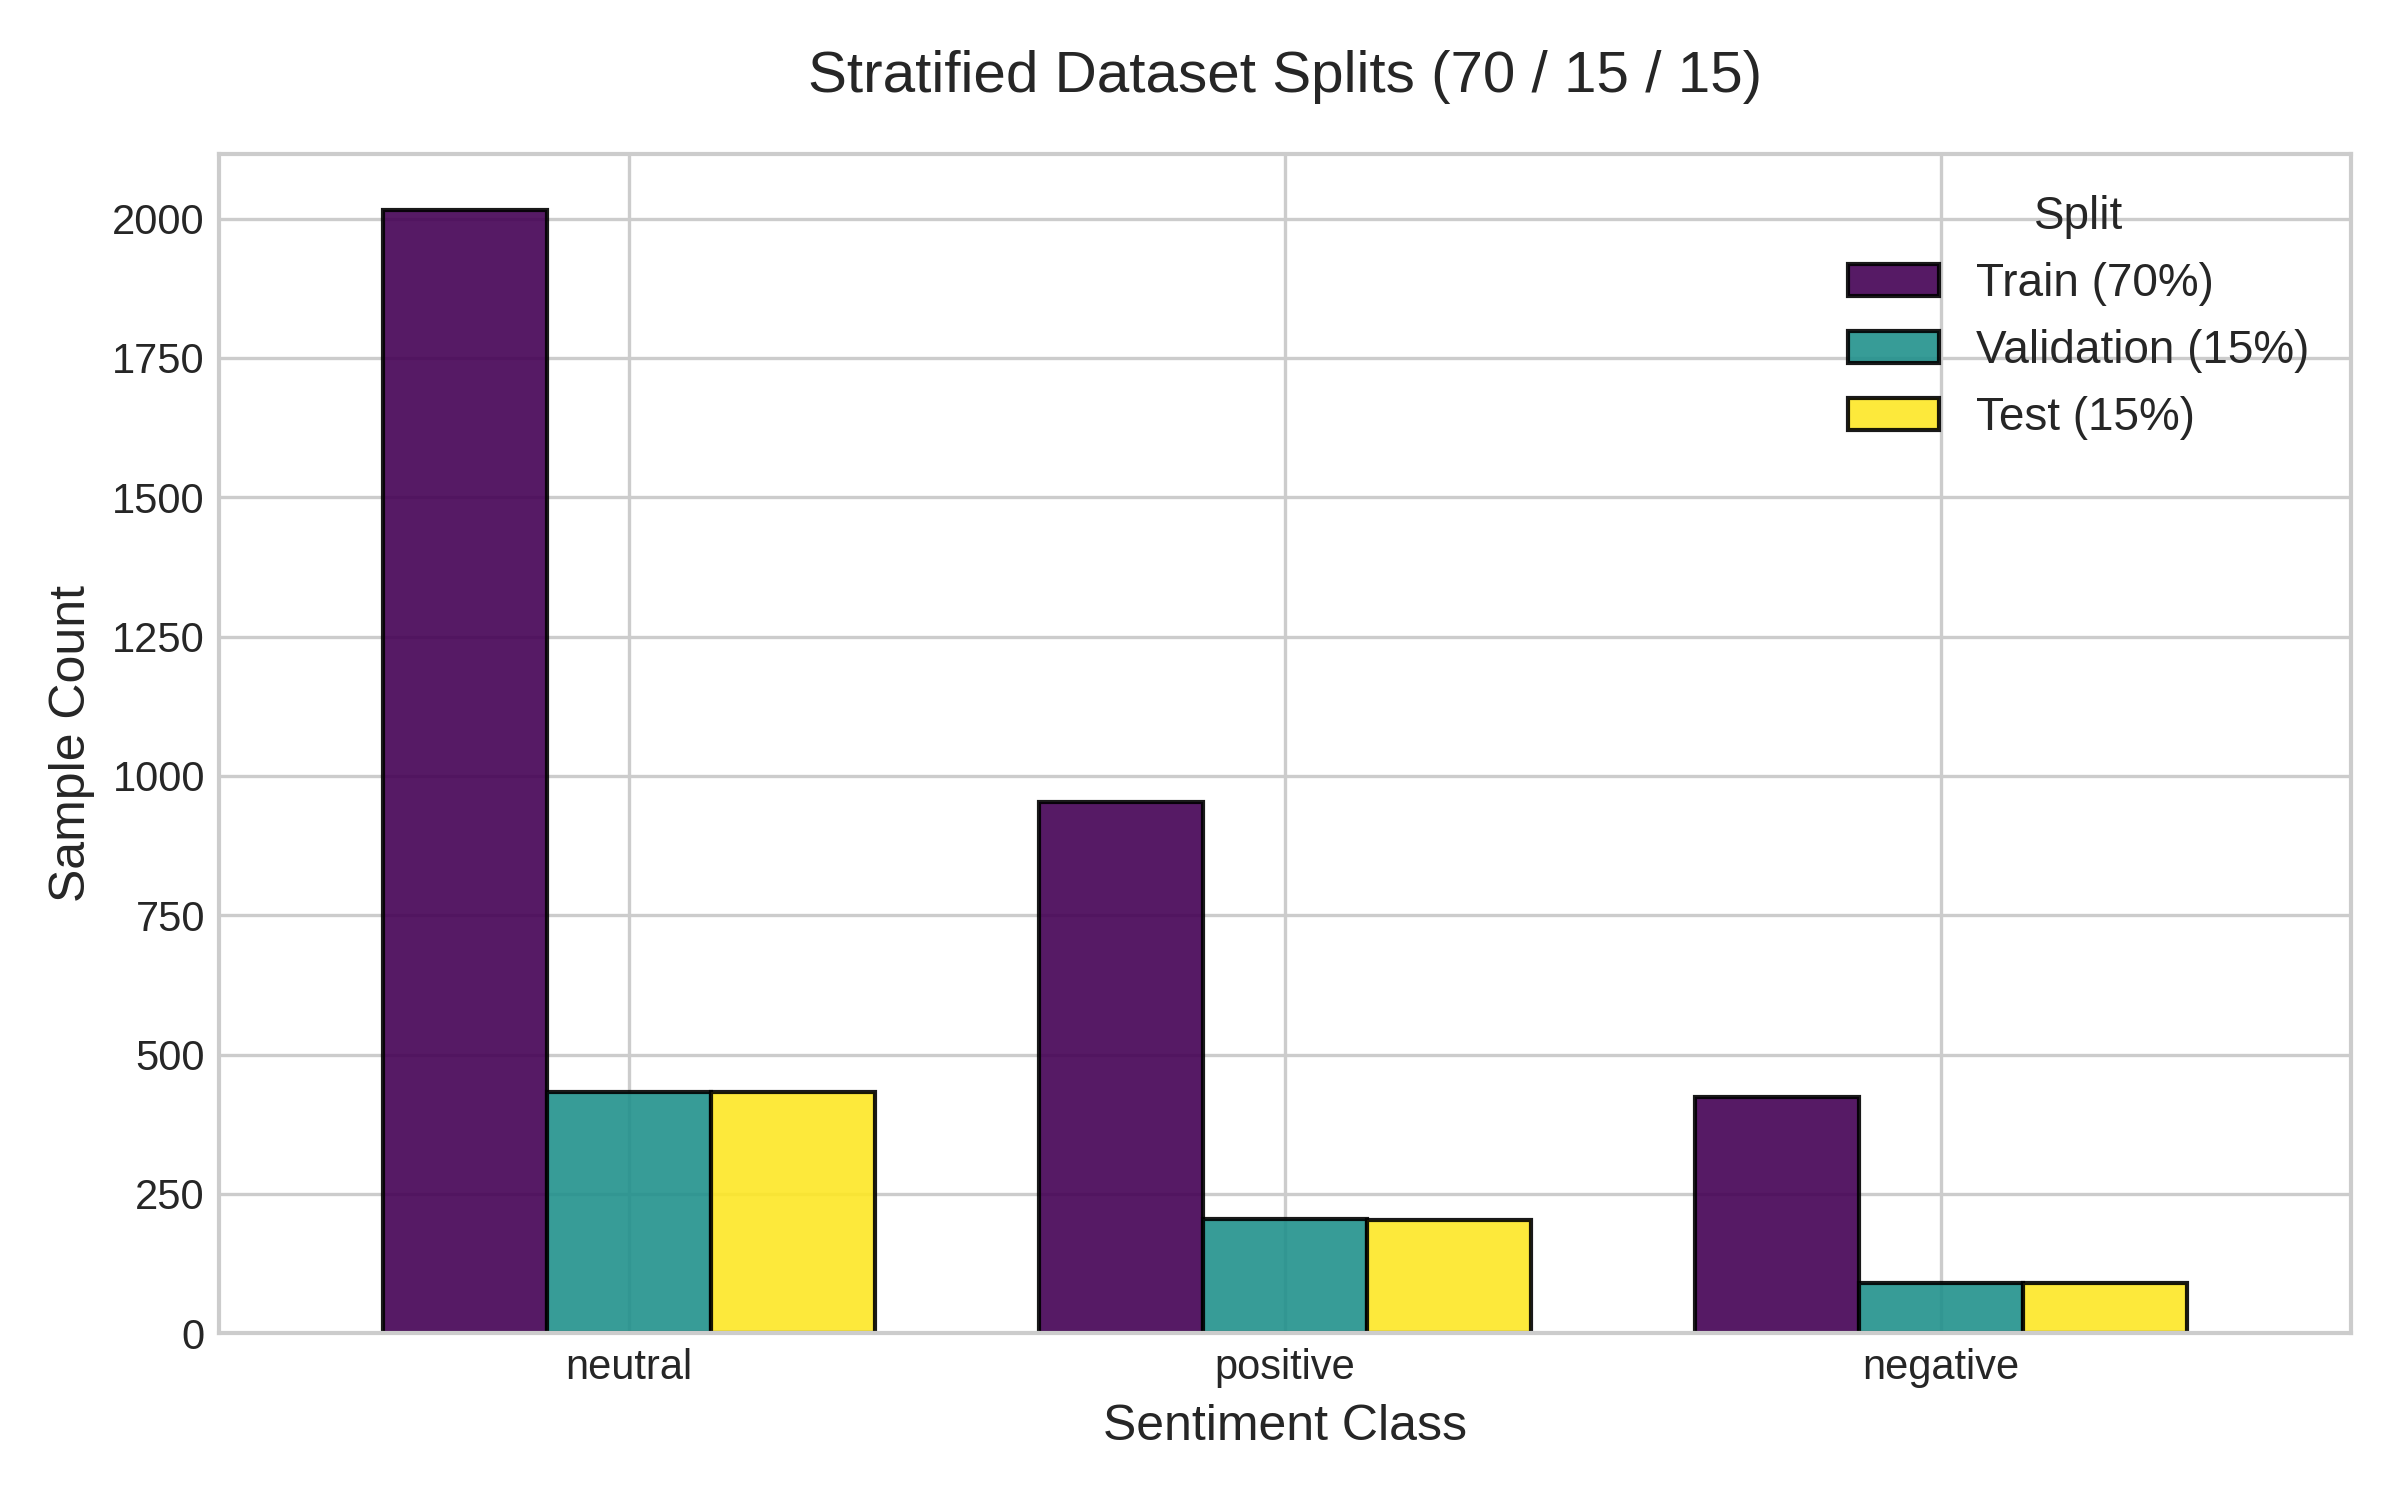

In [ ]:
# Generate and save visualizations
from src.visualization import plot_class_distribution, plot_split_distribution, plot_sentence_lengths
import matplotlib.pyplot as plt

os.makedirs('results/figures', exist_ok=True)

plot_class_distribution(df, save_path='results/figures/class_distribution.png')
plot_split_distribution(train_df, val_df, test_df, save_path='results/figures/split_distribution.png')
plot_sentence_lengths(df, save_path='results/figures/sentence_length_distribution.png')

print('Saved plots to results/figures/:')
print(' - class_distribution.png')
print(' - split_distribution.png')
print(' - sentence_length_distribution.png')

# Display the split distribution chart inline
from IPython.display import Image
Image(filename='results/figures/split_distribution.png')

### Key Takeaways from Dataset Analysis

- The dataset contains **4,846 sentences** with high agreement between annotators.
- The classes are imbalanced: **neutral** represents approximately 60% of samples, followed by **positive** (~28%) and **negative** (~12%).
- The stratified 70/15/15 split maintains the exact class proportion in all three splits.
- Sentence lengths are compact (median ~21 words), well within a `max_sequence_length` of 256 tokens.
- The fixed test set created here will be used without modification across all subsequent experiments.